<a href="https://colab.research.google.com/github/DQ0115/1142programing_language/blob/main/HW2_%E6%88%90%E7%B8%BE%E4%B8%80%E6%9C%AC%E9%80%9A_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

安裝必要的套件

In [17]:
!pip install -q google-generativeai

In [18]:
import gspread # Added for self-containment
from google.colab import auth # Added for self-containment
from google.auth import default # Added for self-containment
from datetime import datetime # Added for self-containment

In [19]:
import gradio as gr
import pandas as pd
from google.colab import auth
from google.auth import default

# -*- coding: utf-8 -*-
import gspread
from datetime import datetime
import google.generativeai as genai
import os
import json

from google.colab import userdata
from google import genai

### 步驟 2: 導入函式庫與設定 API 金鑰

設定 Google Sheet 連線

In [20]:
# Global variables for Google Sheet connection (re-defined here for self-containment of this test cell)
# These should ideally be defined once in cell 9f9fcf48 and that cell executed.
SHEET_URL = "https://docs.google.com/spreadsheets/d/1sa3H9GA7f4fV6cAOVa7huM0Z_QttSlCCBKvewZz5iFA/edit?gid=0#gid=0"
WORKSHEET_NAME = "工作表1"
REQUIRED_COLUMNS = ["日期", "科目", "作業成績"] # Also from cell 9f9fcf48

_gc = None
_ws = None

def setup_gspread(sheet_url, worksheet_name):
    global _gc, _ws
    if _gc is None or _ws is None:
        print("--- 正在進行 Google Sheet 身份驗證和連線... ---")
        try:
            auth.authenticate_user()
            creds, _ = default()
            _gc = gspread.authorize(creds)
            sh = _gc.open_by_url(sheet_url)
            _ws = sh.worksheet(worksheet_name)
            print("--- Google Sheet 連線成功。---")
        except Exception as e:
            print(f"Google Sheet 連線失敗：{e}")
            _gc = None
            _ws = None

In [21]:
# 從 Colab Secrets 中獲取 API 金鑰
api_key = userdata.get('gemini')

# 使用獲取的金鑰配置 genai
client = genai.Client(api_key=api_key)

MODEL_ID = 'gemini-2.5-flash-lite'

# (可選) 測試 AI 模型
response = client.models.generate_content(
    model = MODEL_ID, contents="Explain how AI works in a few words"
)
print(response.text)

AI learns from data to make decisions or predictions.


### 定義 AI 摘要函式

In [22]:
def get_ai_summary(grades):
    """
    呼叫 Gemini 模型來生成成績摘要與常見迷思。
    """
    # 準備給 AI 的提示
    prompt_text = "以下是學生的成績列表，請幫我根據這些成績，產出一個簡單的摘要與常見迷思整理（不評分，只做總結）。\n\n"
    for record in grades:
        date, subject, grade = record
        prompt_text += f"日期：{date}, 科目：{subject}, 成績：{grade}\n"

    print("\n--- 正在呼叫 AI 模型生成摘要... ---")
    try:
        response = client.models.generate_content(model = MODEL_ID, contents = prompt_text)
        summary = response.text
        return summary
    except Exception as e:
        print(f"呼叫 AI 時發生錯誤：{e}")
        return "AI 摘要生成失敗。"

In [23]:
import matplotlib.pyplot as plt

def process_grades_and_summary(grade_data):
    """
    處理 Gradio 介面傳入的成績，寫入 Google Sheet 並生成 AI 摘要和成績圖表。
    grade_data 預期是 [科目, 成績] 的列表的列表，例如：[['國文', 90], ['英文', 85]]
    """
    global _gc, _ws

    if _ws is None:
        # 如果連線失敗，嘗試重新設定 (可能在 Gradio 介面啟動後才執行)
        setup_gspread(SHEET_URL, WORKSHEET_NAME) # Modified to pass arguments
        if _ws is None:
            return "Google Sheet 未能成功連線，請檢查錯誤訊息並重試。", "", None # Return None for plot

    if not grade_data:
        return "沒有輸入任何成績，請輸入科目和成績。", "", None # Return None for plot

    # 準備寫入 Google Sheet 的成績資料，增加日期欄位
    new_grades_for_sheet = []
    subjects = []
    grades_numeric = []
    today = datetime.now().strftime('%Y-%m-%d')
    for subject, grade_str in grade_data:
        try:
            grade = int(grade_str)
            new_grades_for_sheet.append([today, subject, grade])
            subjects.append(subject)
            grades_numeric.append(grade)
        except ValueError:
            return f"科目 '{subject}' 的成績 '{grade_str}' 無效，成績必須是數字。", "", None # Return None for plot

    sheet_message = ""
    try:
        # 將新成績寫入 Google Sheet
        _ws.append_rows(new_grades_for_sheet)
        sheet_message = "成績已成功寫入 Google Sheet。\n"
    except Exception as e:
        sheet_message = f"寫入 Google Sheet 失敗：{e}\n"
        print(f"寫入 Google Sheet 失敗：{e}")
        # 即使寫入失敗，仍嘗試生成 AI 摘要和圖表

    # 獲取 AI 摘要
    summary = get_ai_summary(new_grades_for_sheet)

    try:
        # 尋找第一行空白列來寫入 AI 摘要
        next_row = len(_ws.col_values(1)) + 1
        _ws.update_cell(next_row, 1, datetime.now().strftime('%Y-%m-%d'))
        _ws.update_cell(next_row, 2, 'AI 摘要')

        # 為了避免單元格內容過長，將摘要內容分成多行來寫入
        summary_lines = summary.split('\n')
        for i, line in enumerate(summary_lines):
            # 確保不會寫入太長導致超出單元格限制 (雖然 gspread 會自動換行)
            _ws.update_cell(next_row + i, 3, line)
        sheet_message += "AI 摘要已成功寫入 Google Sheet。"
    except Exception as e:
        sheet_message += f"寫入 AI 摘要到 Google Sheet 失敗：{e}"
        print(f"寫入 AI 摘要到 Google Sheet 失敗：{e}")

    # 生成成績圖表
    fig = None
    if grades_numeric:
        try:
            fig = plt.figure(figsize=(8, 4))
            plt.bar(subjects, grades_numeric, color='skyblue')
            plt.xlabel('科目')
            plt.ylabel('成績')
            plt.title('各科成績概況')
            plt.ylim(0, 100) # 假設成績範圍為 0-100
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
        except Exception as e:
            print(f"生成成績圖表失敗：{e}")
            fig = None

    return sheet_message, summary, fig

--- 正在進行 Google Sheet 身份驗證和連線... ---
--- Google Sheet 連線成功。---

--- 正在執行 process_grades_and_summary 函式單元測試... ---

--- 正在呼叫 AI 模型生成摘要... ---

--- 函式執行結果 --- 
Google Sheet 處理狀態: 成績已成功寫入 Google Sheet。
AI 摘要已成功寫入 Google Sheet。
AI 摘要:
好的，這是一份根據您提供的學生成績所整理的簡單摘要與常見迷思整理：

---

## 學生學習狀況摘要 (2026-04-22)

**整體表現：**

*   今日學生在國文、數學、英文三個科目上均展現了不錯的學習成果。
*   其中，英文成績表現最為突出，國文成績也相當優異。
*   數學成績雖然略低於國文與英文，但也屬於一個穩定的分數區間。

**科目表現概覽：**

*   **國文：** 85 分
*   **數學：** 78 分
*   **英文：** 92 分

**初步觀察：**

*   學生在語言類科目（國文、英文）上似乎有較好的掌握度。
*   數學科目雖然分數相對較低，但仍處於及格以上。

---

## 關於學習表現的常見迷思整理

以下是一些常聽到關於學習成績的觀念，並針對您提供的數據進行一些初步的思考，**請注意，這僅是基於有限數據的討論，不代表最終結論。**

1.  **迷思一：「分數越高就代表越聰明。」**
    *   **說明：** 雖然高分通常代表對該科目的掌握度較高，但「聰明」是一個更廣泛的概念，包含理解力、解決問題的能力、創造力等。單一科目的高分不一定能完全反映一個人的整體聰慧程度。
    *   **在此數據中的思考：** 該學生英文取得高分 (92)，國文 (85) 也很不錯，數學 (78) 雖然略低，但這並不代表學生在數學方面的「聰明」程度就一定不如其他科目。有可能是學習方法、時間投入、對題目的熟悉度等其他因素影響了當下的分數。

2.  **迷思二：「分數低就代表學不會，或是對該科目沒有天賦。」**
    *   **說明：** 分數是特定時間點、特定評量方式下的結果，可能受到許多因素影響，如考試前的準備狀態、對題型的陌生、學習過程中的困難點未被克服、或

/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 22283 (\N{CJK UNIFIED IDEOGRAPH-570B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 23416 (\N{CJK UNIFIED IDEOGRAPH-5B78}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 33521 (\N{CJK UNIFIED IDEOGRAPH-82F1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6039/2751604164.py:73: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}

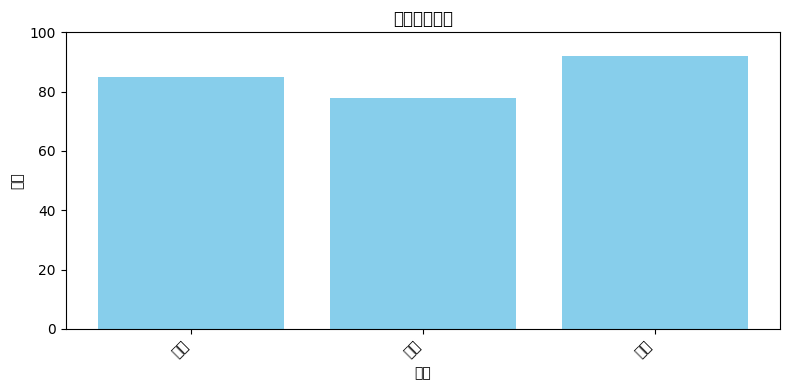

In [24]:
# 確保 Google Sheet 連線已經建立或重新建立
setup_gspread(SHEET_URL, WORKSHEET_NAME)

# 準備測試資料
test_grade_data = [
    ["國文", "85"],
    ["數學", "78"],
    ["英文", "92"]
]

print("\n--- 正在執行 process_grades_and_summary 函式單元測試... ---")

sheet_status, ai_summary_output, _ = process_grades_and_summary(test_grade_data)

print("\n--- 函式執行結果 --- ")
print(f"Google Sheet 處理狀態: {sheet_status}")
print(f"AI 摘要:\n{ai_summary_output}")

# 檢查 _ws 是否為 None，判斷 Google Sheet 是否真的連線成功
if _ws is None:
    print("\n注意：Google Sheet 工作表物件 (_ws) 仍為 None，表示連線可能仍有問題。")
else:
    print("\nGoogle Sheet 工作表物件 (_ws) 已成功初始化，連線似乎已建立。")

定義 Gradio 處理函式

In [25]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("# 成績輸入與 AI 摘要工具")
    gr.Markdown("請在下方的表格中輸入學生的科目和成績，然後點擊『送出』。系統會將資料寫入 Google Sheet 並生成 AI 摘要。")

    with gr.Row():
        with gr.Column():
            grade_input = gr.Dataframe(
                headers=["科目", "成績"],
                value=[["", ""]],
                type="array",
                row_count=1,
                col_count=(2, "fixed"),
                label="輸入科目與成績 (點擊最後一行可新增)"
            )
            submit_button = gr.Button("送出")

        with gr.Column():
            sheet_output = gr.Textbox(label="Google Sheet 處理狀態")
            grade_plot = gr.Plot(label="成績概況", show_label=True)
            summary_output = gr.Textbox(label="AI 摘要", lines=15)

    submit_button.click(
        process_grades_and_summary,
        inputs=grade_input,
        outputs=[sheet_output, summary_output, grade_plot]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7eac8714eca2690085.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
